**Load Dataset**

In [1]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("iqbalpurba26/health-topic-dataset")

train_df = dataset["train"].to_pandas()

train_df.head()

,topic,intent
0,vitamin untuk alergi kulit merah dan gatal yan...,0
1,obat untuk mengatasi gatalgatal pada anak,0
2,kulit hidung gatal hingga memerah apa penyebabnya,0
3,apa obat batuk alergi tenggorokan gatal,0
4,wajah merah dan gatal menandakan gejala apa,0


In [2]:
import pandas as pd

menstruation_df = train_df[train_df["intent"] == 2].copy()

menstruation_df = menstruation_df.rename(columns={
    "topic": "pertanyaan"
})

# hanya ambil kolom yang dibutuhkan
menstruation_df = menstruation_df[["pertanyaan"]]

print(menstruation_df.head())

                                             pertanyaan
8940   penyebab haid datang lebih cepat tanda kehamilan
8941  apakah pusing dan lemas merupakan anemia saat ...
8942    keluar gumpalan daging sebesar jempol saat haid
8943               haid  hari warna coklat apakah hamil
8944     telat haid  hari keluar darah apakah keguguran


In [3]:
scraping_df = pd.read_csv("dataset_menstruasi.csv")

scraping_df = scraping_df[["pertanyaan", "jawaban"]]

print(scraping_df.head())

                                   pertanyaan  \
0                         Apa itu menstruasi?   
1              Apa yang dimaksud dengan haid?   
2        Mengapa wanita mengalami menstruasi?   
3      Kapan pertama kali menstruasi terjadi?   
4  Apakah menstruasi merupakan proses normal?   

                                             jawaban  
0  Menstruasi adalah proses alami keluarnya darah...  
1         Haid adalah istilah lain untuk menstruasi.  
2  Karena tubuh meluruhkan lapisan rahim yang tid...  
3  Umumnya saat pubertas, meskipun usia setiap or...  
4  Ya, menstruasi adalah proses biologis yang nor...  


In [4]:
print(f"Jumlah data pada menstruation_df: {len(menstruation_df)}")
print(f"Jumlah data pada scraping_df: {len(scraping_df)}")

Jumlah data pada menstruation_df: 4506
Jumlah data pada scraping_df: 507


**Preprocessing**

In [ ]:
import re

def preprocessing(text):
    # mengubah teks menjadi huruf kecil
    text = text.lower()
    # menghapus link url pada teks
    text = re.sub(r"http\S+", "", text)
    # menghapus teks selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    # menghapus spasi yang berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
# Kode ini berguna untuk membersihkan teks pada kolom "pertanyaan" di menstruation_df. 
menstruation_df["clean"] = menstruation_df["pertanyaan"].fillna("").apply(preprocessing)
# Kode ini berguna untuk membersihkan teks pada kolom "pertanyaan" di scraping_df.
scraping_df["clean"] = scraping_df["pertanyaan"].fillna("").apply(preprocessing)

**Model Embedding SBERT**

In [ ]:
from sentence_transformers import SentenceTransformer
# load model embedding dari SentenceBERT
embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Kode ini berguna untuk membuat embedding dari teks yang telah dibersihkan pada menstruation_df menggunakan model embedding yang telah dimuat sebelumnya. 
# Embedding ini akan digunakan untuk analisis lebih lanjut, seperti pencarian semantik.
hf_embeddings = embedding_model.encode(
    menstruation_df["clean"].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)
# Kode ini berguna untuk membuat embedding dari teks yang telah dibersihkan pada scraping_df menggunakan model embedding Sbert yang telah dimuat sebelumnya.
scraping_embeddings = embedding_model.encode(
    scraping_df["clean"].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/141 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

**Semantic Matching**

In [ ]:
from sentence_transformers import util

#Kode ini berguna untuk menandakan threshold kesamaan yang digunakan dalam pencarian.
THRESHOLD = 0.80
# Kode ini berguna untuk menyimpan hasil pencarian kesamaan kosinus ke dalam list baru.
new_dataset = []

In [ ]:
for i, question in enumerate(menstruation_df["pertanyaan"]):

    # menghitung kesamaan kosinus antara embedding dari pertanyaan di menstruation_df dengan semua embedding di scraping_df
    scores = util.cos_sim(
        hf_embeddings[i],
        scraping_embeddings
    )[0]

    # mendapatkan skor kesamaan tertinggi dan indeksnya
    best_score = scores.max().item()
    # mendapatkan indeks dari skor kesamaan tertinggi
    best_index = scores.argmax().item()

    # jika skor kesamaan tertinggi lebih besar atau sama dengan THRESHOLD, maka simpan pertanyaan, jawaban, dan skor kesamaan ke dalam new_dataset
    if best_score >= THRESHOLD:
        # simpan pertanyaan, jawaban, dan skor kesamaan ke dalam new_dataset
        new_dataset.append({
            "pertanyaan": question,
            "jawaban": scraping_df.iloc[best_index]["jawaban"],
            "similarity": best_score
        })

**Dataset Final = knowledge_base**

In [ ]:
import pandas as pd
# Kode ini berguna untuk mengubah list new_dataset menjadi DataFrame pandas.
final_dataset = pd.DataFrame(new_dataset)
# Kode ini berguna untuk menampilkan lima baris pertama dari DataFrame final_dataset.
print(final_dataset.head())

                                          pertanyaan  \
0  apakah pusing dan lemas merupakan anemia saat ...   
1     telat haid  hari keluar darah apakah keguguran   
2            ciriciri kista keluar dengan darah haid   
3          haid datang lebih awal apakah tanda hamil   
4         penyebab keluar darah setelah haid  minggu   

                                             jawaban  similarity  
0  Ya. Kehilangan darah dalam jumlah besar secara...    0.923548  
1  Masalah ini erat kaitannya dengan fluktuasi ho...    0.843800  
2  Dapat dipengaruhi hormon, usia, atau kontrasepsi.    0.831710  
3  Masalah ini erat kaitannya dengan fluktuasi ho...    0.804213  
4  Menstruasi umumnya berlangsung antara tiga hin...    0.812263  


In [ ]:
knowledge_base = pd.concat([
    # Kode ini berguna untuk menggabungkan DataFrame scraping_df dan final_dataset menjadi satu DataFrame baru bernama knowledge_base, 
    # yang berisi pertanyaan dan jawaban unik.
    scraping_df[["pertanyaan","jawaban"]],

    final_dataset[["pertanyaan","jawaban"]]

]).drop_duplicates().reset_index(drop=True)

In [ ]:
knowledge_base["pertanyaan"] = knowledge_base["pertanyaan"].fillna("")
knowledge_base["pertanyaan"] = knowledge_base["pertanyaan"].astype(str)
# Kode ini berguna untuk membersihkan teks pada kolom "pertanyaan" di knowledge_base.
knowledge_base["clean"] = knowledge_base["pertanyaan"].apply(preprocessing)

**Split Dataset**

In [ ]:
from sklearn.model_selection import train_test_split

# Kode ini berguna untuk membagi knowledge_base menjadi dua set data: knowledge_train dan testing_df.
knowledge_train, testing_df = train_test_split(
    knowledge_base,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
# Kode ini berguna untuk mereset indeks pada DataFrame knowledge_train dan testing_df agar dimulai dari 0.
knowledge_train = knowledge_train.reset_index(drop=True)
testing_df = testing_df.reset_index(drop=True)

print("Knowledge Base :", len(knowledge_train))
print("Testing :", len(testing_df))

Knowledge Base : 1363
Testing : 341


In [ ]:
# Kode ini berguna untuk menyimpan DataFrame knowledge_train dan testing_df ke dalam file CSV tanpa menyertakan indeks baris.
knowledge_train.to_csv("knowledge_base.csv", index=False)
testing_df.to_csv("testing.csv", index=False)

**Embedding Knowledge Base**

In [ ]:
# 1. Mengubah data kosong (NaN) menjadi string kosong ""
knowledge_base["pertanyaan"] = knowledge_base["pertanyaan"].fillna("")

# 2. Pastikan seluruh kolom bertipe string
knowledge_base["pertanyaan"] = knowledge_base["pertanyaan"].astype(str)

# 3. Jalankan kembali preprocessing-nya
knowledge_base["clean"] = knowledge_base["pertanyaan"].apply(preprocessing)

# 4. Buat embedding untuk knowledge_base
faq_embeddings = embedding_model.encode(
    knowledge_base["clean"].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/54 [00:00<?, ?it/s]

**Save Model**

In [ ]:
import pickle
# Kode ini berguna untuk menyimpan DataFrame knowledge_base ke dalam file CSV tanpa menyertakan indeks baris.
knowledge_base.to_csv(
    "knowledge_base.csv",
    index=False
)
# Kode ini berguna untuk menyimpan embedding dari knowledge_base ke dalam file model_sbert.pkl menggunakan modul pickle.
pickle.dump(
    faq_embeddings,
    open("model_sbert.pkl","wb")
)

**Chatbox**

In [ ]:
# Menentukan nilai ambang (threshold) similarity sebesar 0.80.
# Jika nilai cosine similarity di atas atau sama dengan 0.80,
# maka jawaban dianggap cukup relevan untuk ditampilkan.
THRESHOLD = 0.80


# Mendefinisikan fungsi chatbot_sbert yang menerima satu parameter berupa pertanyaan dari pengguna.
def chatbot_sbert(question):

    # Memanggil fungsi preprocessing untuk membersihkan teks pertanyaan,
    # seperti mengubah huruf menjadi lowercase, menghapus tanda baca,
    # atau proses pembersihan lainnya yang telah dibuat sebelumnya.
    clean = preprocessing(question)

    # Mengubah pertanyaan yang telah diproses menjadi embedding (representasi vektor)
    # menggunakan model Sentence-BERT.
    # convert_to_tensor=True digunakan agar hasil embedding berupa tensor PyTorch
    # sehingga dapat langsung digunakan untuk perhitungan similarity.
    query_embedding = embedding_model.encode(
        clean,
        convert_to_tensor=True
    )

    # Menghitung cosine similarity antara embedding pertanyaan pengguna
    # dengan seluruh embedding FAQ yang telah disimpan sebelumnya.
    # util.cos_sim() menghasilkan matriks similarity,
    # sedangkan [0] mengambil baris pertama karena hanya ada satu query.
    scores = util.cos_sim(
        query_embedding,
        faq_embeddings
    )[0]

    # Mengambil nilai similarity terbesar dari seluruh hasil perbandingan.
    # .item() digunakan untuk mengubah tensor menjadi nilai numerik biasa (float).
    best_score = scores.max().item()

    # Mengambil indeks FAQ yang memiliki nilai similarity tertinggi.
    # .argmax() mencari posisi nilai terbesar,
    # kemudian .item() mengubahnya menjadi integer.
    best_index = scores.argmax().item()

    # Mengecek apakah nilai similarity tertinggi memenuhi threshold yang telah ditentukan.
    if best_score >= THRESHOLD:

        # Jika memenuhi threshold,
        # maka mengembalikan dictionary yang berisi:
        # - pertanyaan FAQ yang paling mirip,
        # - jawaban FAQ tersebut,
        # - nilai similarity.
        return {
            "Pertanyaan": knowledge_base.iloc[best_index]["pertanyaan"],
            "Jawaban": knowledge_base.iloc[best_index]["jawaban"],
            "Similarity": round(best_score, 4)
        }

    # Jika similarity tidak memenuhi threshold,
    # maka dianggap tidak ditemukan jawaban yang cukup relevan.
    else:

        # Mengembalikan pesan bahwa chatbot belum menemukan jawaban yang sesuai,
        # beserta nilai similarity tertinggi sebagai informasi.
        return {
            "Jawaban": "Maaf, saya belum menemukan jawaban yang sesuai.",
            "Similarity": round(best_score, 4)
        }

In [ ]:
# kode ini berguna untuk menguji fungsi chatbot_sbert dengan pertanyaan "Kenapa haid saya telat?" dan menampilkan hasilnya.
chatbot_sbert("Kenapa haid saya telat?")

{'Pertanyaan': 'Mengapa haid saya terlambat?',
 'Jawaban': 'Keterlambatan menstruasi tidak selalu disebabkan oleh kehamilan. Penyebab lain dapat berupa stres, perubahan hormon, pola makan, aktivitas fisik yang berat, atau kondisi medis tertentu.',
 'Similarity': 0.9866}

In [ ]:
# Mencetak garis pemisah sepanjang 60 karakter "="
# agar tampilan chatbot lebih rapi.
print("=" * 60)

# Menampilkan judul chatbot kepada pengguna.
print("🤖 Chatbot Menstruasi")

# Memberikan petunjuk bahwa pengguna dapat mengetik
# 'exit' atau 'keluar' untuk menghentikan program.
print("Ketik 'exit' atau 'keluar' untuk mengakhiri.")

# Mencetak kembali garis pemisah sebagai penutup header.
print("=" * 60)


# Membuat perulangan tanpa batas agar chatbot
# dapat terus menerima pertanyaan dari pengguna.
while True:

    # Menampilkan prompt input agar pengguna
    # dapat mengetikkan pertanyaan.
    question = input("\n👤 Anda : ")

    # Mengecek apakah input pengguna adalah
    # 'exit', 'keluar', atau 'quit'.
    # lower() digunakan agar input tidak membedakan
    # huruf besar maupun huruf kecil.
    if question.lower() in ["exit", "keluar", "quit"]:

        # Menampilkan pesan perpisahan kepada pengguna.
        print("\n🤖 Chatbot : Terima kasih telah menggunakan chatbot. Sampai jumpa!")

        # Menghentikan perulangan while sehingga
        # program chatbot selesai dijalankan.
        break

    # Memanggil fungsi chatbot_sbert() untuk mencari
    # jawaban yang paling sesuai dengan pertanyaan pengguna.
    result = chatbot_sbert(question)

    # Menampilkan jawaban chatbot yang terdapat
    # pada key 'Jawaban' dalam dictionary hasil.
    print(f"\n🤖 Chatbot : {result['Jawaban']}")

    # Menampilkan nilai cosine similarity antara
    # pertanyaan pengguna dan data FAQ.
    # :.4f digunakan untuk menampilkan 4 angka di belakang koma.
    print(f"📊 Similarity : {result['Similarity']:.4f}")

    # Mengecek apakah dictionary hasil memiliki
    # key 'Pertanyaan'. Key ini hanya ada jika
    # similarity memenuhi threshold.
    if "Pertanyaan" in result:

        # Menampilkan pertanyaan pada knowledge base
        # yang memiliki tingkat kemiripan paling tinggi
        # dengan pertanyaan pengguna.
        print(f"📌 Pertanyaan yang cocok : {result['Pertanyaan']}")

🤖 Chatbot Menstruasi
Ketik 'exit' atau 'keluar' untuk mengakhiri.

👤 Anda : apa itu mesntruasi

🤖 Chatbot : Maaf, saya belum menemukan jawaban yang sesuai.
📊 Similarity : 0.6304

👤 Anda : apa itu menstruasi

🤖 Chatbot : Menstruasi adalah proses alami keluarnya darah dan jaringan dari rahim sebagai bagian dari siklus reproduksi ketika tidak terjadi kehamilan.
📊 Similarity : 1.0000
📌 Pertanyaan yang cocok : Apa itu menstruasi?

👤 Anda : kenapa spain kalah

🤖 Chatbot : Maaf, saya belum menemukan jawaban yang sesuai.
📊 Similarity : 0.4859

👤 Anda : berapa lama durasi haid

🤖 Chatbot : Umumnya 3–7 hari.
📊 Similarity : 0.9666
📌 Pertanyaan yang cocok : Berapa lama haid berlangsung?


KeyboardInterrupt: Interrupted by user

**IndoBert**

In [ ]:
# Kode ini berguna untuk menginstal library transformers dan torch yang diperlukan untuk menjalankan model Indobert.
!pip install transformers torch

In [ ]:
# Kode ini digunakan untuk menentukan nama model IndoBERT yang akan digunakan.
# Model "indobenchmark/indobert-base-p1" merupakan model pretrained IndoBERT yang telah dilatih menggunakan dataset bahasa Indonesia.
model_name = "indobenchmark/indobert-base-p1"


# Kode ini digunakan untuk memuat tokenizer dari model IndoBERT.
# Tokenizer berfungsi untuk mengubah teks input menjadi token atau representasi angka yang dapat dipahami oleh model.
# Tokenizer yang digunakan harus sesuai dengan model agar proses tokenisasi mengikuti aturan saat model dilatih.
tokenizer = AutoTokenizer.from_pretrained(model_name)


# Kode ini digunakan untuk memuat model IndoBERT pretrained dari Hugging Face.
# AutoModel digunakan untuk mengambil arsitektur model transformer tanpa menambahkan layer klasifikasi.
# Output dari model berupa representasi embedding dari teks yang dapat digunakan untuk berbagai tugas NLP,
# seperti pencarian kemiripan teks, klasifikasi, atau clustering.
model = AutoModel.from_pretrained(model_name)


# Kode ini digunakan untuk mengubah model ke mode evaluasi (evaluation mode).
# Mode eval menonaktifkan proses training seperti dropout sehingga hasil inferensi menjadi lebih konsisten.
# Perintah ini digunakan ketika model hanya digunakan untuk menghasilkan prediksi atau embedding, bukan untuk dilatih kembali.
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
# Fungsi ini digunakan untuk menghasilkan embedding dari sekumpulan teks menggunakan model IndoBERT.
# Parameter texts berisi kumpulan kalimat yang akan diubah menjadi vektor numerik.
# Parameter batch_size digunakan untuk menentukan jumlah teks yang diproses dalam satu iterasi agar penggunaan memori lebih efisien.
def bert_embedding(texts, batch_size=16):


    # List kosong untuk menyimpan hasil embedding dari setiap batch teks.
    embeddings = []


    # Melakukan perulangan terhadap data teks dengan ukuran batch tertentu.
    # Fungsi range digunakan agar teks diproses secara bertahap sesuai ukuran batch_size.
    for i in range(0, len(texts), batch_size):


        # Mengambil sekumpulan teks sesuai ukuran batch yang telah ditentukan.
        # Contohnya jika batch_size=16, maka setiap iterasi akan memproses 16 teks.
        batch = texts[i:i+batch_size]


        # Melakukan proses tokenisasi terhadap kumpulan teks.
        # Tokenizer mengubah teks menjadi token ID yang dapat diproses oleh model IndoBERT.
        # padding=True digunakan agar semua teks dalam satu batch memiliki panjang token yang sama.
        # truncation=True digunakan untuk memotong teks yang melebihi batas panjang maksimum.
        # max_length=128 menentukan panjang maksimal token yang digunakan.
        # return_tensors="pt" mengubah hasil tokenisasi menjadi format tensor PyTorch.
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )


        # Menonaktifkan perhitungan gradient selama proses ekstraksi embedding.
        # Hal ini dilakukan karena model tidak digunakan untuk training, sehingga dapat menghemat memori dan mempercepat proses.
        with torch.no_grad():


            # Memasukkan hasil tokenisasi ke dalam model IndoBERT untuk mendapatkan representasi teks.
            # Output model berisi representasi embedding pada setiap token.
            output = model(**encoded)


        # Mengambil representasi embedding dari setiap token pada seluruh kalimat.
        # last_hidden_state memiliki dimensi:
        # (jumlah data, panjang token, ukuran embedding).
        # Pada IndoBERT, setiap token direpresentasikan dalam bentuk vektor berdimensi 768.
        token_embeddings = output.last_hidden_state


        # Mengambil attention mask hasil tokenisasi.
        # Attention mask digunakan untuk membedakan token asli dengan token padding.
        # Nilai 1 menunjukkan token asli, sedangkan nilai 0 menunjukkan token padding.
        attention_mask = encoded["attention_mask"]


        # Mengubah dimensi attention mask agar sesuai dengan ukuran token_embeddings.
        # Hal ini diperlukan agar dapat melakukan perkalian antara embedding token dengan mask.
        mask = attention_mask.unsqueeze(-1).expand(
            token_embeddings.size()
        ).float()


        # Menjumlahkan seluruh embedding token yang valid berdasarkan attention mask.
        # Token padding tidak ikut dihitung karena memiliki nilai mask 0.
        summed = torch.sum(
            token_embeddings * mask,
            dim=1
        )


        # Menghitung jumlah token valid pada setiap kalimat.
        # torch.clamp digunakan untuk mencegah pembagian dengan nilai nol.
        counts = torch.clamp(
            mask.sum(dim=1),
            min=1e-9
        )


        # Melakukan mean pooling untuk mendapatkan satu vektor representasi dari setiap kalimat.
        # Proses ini menghitung rata-rata embedding seluruh token valid.
        # Hasil akhirnya adalah sentence embedding yang merepresentasikan makna keseluruhan kalimat.
        sentence_embedding = summed / counts


        # Menyimpan hasil embedding dari batch saat ini ke dalam list embeddings.
        embeddings.append(sentence_embedding)


    # Menggabungkan seluruh embedding dari setiap batch menjadi satu tensor besar.
    # Output akhir berupa kumpulan vektor embedding untuk seluruh teks input.
    return torch.cat(embeddings)

In [ ]:
# Kode ini digunakan untuk menghasilkan embedding dari data teks yang terdapat pada kolom "clean"
# menggunakan fungsi bert_embedding() yang sebelumnya telah dibuat.
# Embedding yang dihasilkan merupakan representasi numerik dari teks menggunakan model IndoBERT.
hf_embeddings = bert_embedding(
    menstruation_df["clean"].tolist(),
    batch_size=16
)

In [ ]:
scraping_embeddings = bert_embedding(
    scraping_df["clean"].tolist(),
    batch_size=16
)

In [ ]:
# Kode ini digunakan untuk mengimpor library PyTorch yang digunakan untuk operasi tensor dan perhitungan similarity.
import torch

# Kode ini digunakan untuk mengimpor fungsi-fungsi pada PyTorch, salah satunya cosine_similarity
# yang digunakan untuk mengukur tingkat kemiripan antar embedding teks.
import torch.nn.functional as F

# Kode ini digunakan untuk mengimpor pandas yang digunakan untuk mengelola data dalam bentuk DataFrame.
import pandas as pd

# Kode ini digunakan untuk mengimpor komponen tokenizer dan model dari library Hugging Face Transformers.
# AutoTokenizer digunakan untuk melakukan tokenisasi teks, sedangkan AutoModel digunakan untuk memuat model transformer.
from transformers import AutoTokenizer, AutoModel



# List kosong yang digunakan untuk menyimpan data baru hasil proses pencarian kemiripan.
# Data yang memiliki similarity di atas threshold akan dimasukkan ke dalam list ini.
new_dataset = []


# Menentukan batas minimal nilai similarity agar dua pertanyaan dianggap memiliki kemiripan.
# Nilai 0.80 berarti hanya pasangan pertanyaan dengan tingkat kemiripan 80% atau lebih yang akan dipilih.
THRESHOLD = 0.80



# Melakukan perulangan terhadap seluruh pertanyaan pada dataset utama.
# enumerate digunakan agar mendapatkan index (i) dan nilai pertanyaan (question).
for i, question in enumerate(
    menstruation_df["pertanyaan"]
):


    # Mengambil embedding dari pertanyaan berdasarkan index saat ini.
    # Embedding ini merupakan representasi vektor dari pertanyaan yang sebelumnya dihasilkan menggunakan IndoBERT.
    query_embedding = hf_embeddings[i]



    # Menghitung cosine similarity antara embedding pertanyaan dari dataset utama
    # dengan seluruh embedding pada scraping_embeddings.
    #
    # Cosine similarity mengukur tingkat kemiripan arah dua buah vektor.
    # Nilai mendekati 1 menunjukkan teks memiliki makna yang semakin mirip.
    scores = F.cosine_similarity(
        query_embedding.unsqueeze(0),
        scraping_embeddings
    )



    # Mengambil nilai similarity tertinggi dari seluruh hasil perbandingan.
    # .max() menghasilkan nilai similarity paling besar, kemudian .item()
    # digunakan untuk mengubah tensor menjadi nilai Python float.
    best_score = scores.max().item()



    # Mengambil index dari embedding dengan nilai similarity tertinggi.
    # Index ini digunakan untuk mencari data jawaban yang paling sesuai pada scraping_df.
    best_index = scores.argmax().item()



    # Melakukan pengecekan apakah nilai similarity terbaik memenuhi threshold.
    # Jika similarity >= 0.80, maka data dianggap memiliki pasangan pertanyaan yang mirip.
    if best_score >= THRESHOLD:


        # Menambahkan pasangan pertanyaan dan jawaban yang memiliki similarity tinggi
        # ke dalam dataset baru.
        new_dataset.append({


            # Menyimpan pertanyaan asli dari dataset utama.
            "pertanyaan": question,


            # Mengambil jawaban dari dataset hasil scraping berdasarkan index dengan similarity tertinggi.
            # Jawaban ini dianggap sebagai jawaban yang paling relevan terhadap pertanyaan.
            "jawaban": scraping_df.iloc[best_index]["jawaban"],


            # Menyimpan nilai similarity sebagai informasi tingkat kemiripan.
            # Nilai ini dapat digunakan untuk evaluasi atau analisis kualitas matching.
            "similarity": best_score
        })

In [ ]:
# Kode ini digunakan untuk mengubah list new_dataset menjadi DataFrame pandas.
final_dataset = pd.DataFrame(new_dataset)

In [ ]:
# Kode ini digunakan untuk menggabungkan dua sumber data yaitu dataset hasil scraping
# dan dataset hasil proses matching/augmentasi menjadi satu knowledge base.
# Knowledge base ini nantinya digunakan sebagai kumpulan referensi pertanyaan dan jawaban chatbot.
knowledge_base = pd.concat([
    # Mengambil kolom "pertanyaan" dan "jawaban" dari dataset scraping.
    # Dataset ini berisi data awal hasil pengumpulan informasi dari proses scraping.
    scraping_df[["pertanyaan","jawaban"]],
    # Mengambil kolom "pertanyaan" dan "jawaban" dari final_dataset.
    # Dataset ini berisi data tambahan yang telah melalui proses semantic matching
    # berdasarkan nilai similarity menggunakan embedding IndoBERT.
    final_dataset[["pertanyaan","jawaban"]]
# Menggabungkan kedua dataframe menjadi satu dataframe baru.
# pd.concat() melakukan penggabungan data secara vertikal (menambahkan baris baru).
]).drop_duplicates().reset_index(drop=True)

In [ ]:
# Kode ini digunakan untuk memastikan kolom "pertanyaan" pada knowledge_base
# memiliki format data yang sesuai sebelum dilakukan proses preprocessing.
# Data pertanyaan akan dibersihkan dari nilai kosong dan dikonversi menjadi tipe string.

knowledge_base["pertanyaan"] = (
    # Mengisi nilai kosong (NaN) pada kolom "pertanyaan" dengan string kosong.
    # Hal ini dilakukan agar proses pengolahan teks tidak mengalami error
    # ketika menemukan data yang tidak memiliki nilai.
    knowledge_base["pertanyaan"]
    .fillna("")
    # Mengubah seluruh data pada kolom "pertanyaan" menjadi tipe data string.
    # Proses ini memastikan seluruh isi kolom dapat diproses oleh fungsi preprocessing.
    .astype(str)

)

# Kode ini digunakan untuk membuat kolom baru bernama "clean".
# Kolom ini berisi hasil preprocessing dari teks pertanyaan pada knowledge_base.
# Data pada kolom ini nantinya digunakan untuk proses ekstraksi embedding.
knowledge_base["clean"] = (
    # Mengambil data pertanyaan yang telah dibersihkan dari nilai kosong
    # dan dikonversi menjadi string.
    knowledge_base["pertanyaan"]
    # Menerapkan fungsi preprocessing ke setiap teks pertanyaan.
    # Fungsi preprocessing biasanya melakukan proses seperti:
    # - mengubah huruf menjadi lowercase
    # - menghapus tanda baca
    # - menghapus karakter tidak diperlukan
    # - normalisasi kata
    # - membersihkan whitespace
    .apply(preprocessing)
)

In [ ]:
# Kode ini digunakan untuk menghasilkan embedding dari seluruh pertanyaan
# yang terdapat pada knowledge_base menggunakan model IndoBERT.
# Embedding ini akan menjadi representasi numerik dari setiap pertanyaan
# yang digunakan pada proses pencarian jawaban berdasarkan kemiripan makna.

knowledge_embeddings = bert_embedding(
    # Mengambil kolom "clean" dari knowledge_base kemudian mengubahnya
    # menjadi list agar dapat diproses oleh fungsi bert_embedding().
    # Kolom "clean" berisi pertanyaan yang telah melalui tahap preprocessing.
    knowledge_base["clean"].tolist(),
    # Menentukan jumlah teks yang diproses dalam satu batch.
    # Sebanyak 16 pertanyaan akan diproses secara bersamaan dalam satu iterasi
    # untuk mengoptimalkan penggunaan memori saat melakukan inferensi IndoBERT.
    batch_size=16
)

In [ ]:
# Kode ini digunakan untuk mengimpor library pickle yang berfungsi untuk menyimpan
# dan membaca objek Python dalam bentuk file.
import pickle
# Kode ini digunakan untuk menyimpan knowledge base ke dalam format CSV.
# File ini berisi kumpulan pertanyaan dan jawaban yang akan digunakan sebagai
# sumber pengetahuan chatbot.
knowledge_base.to_csv(
    "knowledge_base_bert.csv",
    index=False
)
# Kode ini digunakan untuk menyimpan hasil embedding IndoBERT ke dalam file pickle (.pkl).
# File ini berisi representasi vektor dari setiap pertanyaan pada knowledge base
# yang nantinya digunakan untuk proses pencarian similarity.
pickle.dump(
    knowledge_embeddings,
    open("model_indobert.pkl","wb")
)

In [ ]:
# Kode ini digunakan untuk mengimpor library PyTorch.
# torch digunakan untuk operasi tensor, sedangkan torch.nn.functional digunakan
# untuk fungsi tambahan seperti normalisasi embedding.
import torch
import torch.nn.functional as F


# Menentukan batas minimal similarity agar jawaban dianggap relevan.
# Jika nilai similarity >= 0.80, chatbot akan memberikan jawaban dari knowledge base.
THRESHOLD = 0.80


# Fungsi utama chatbot berbasis IndoBERT.
# Fungsi ini menerima input pertanyaan pengguna dan mencari jawaban paling mirip
# dari knowledge base.
def chatbot_indobert(question):
    # Melakukan preprocessing terhadap pertanyaan pengguna
    # agar memiliki format yang sama dengan data knowledge base.
    clean = preprocessing(question)
    # Mengubah pertanyaan pengguna menjadi embedding menggunakan IndoBERT.
    # Hasilnya berupa vektor yang merepresentasikan makna pertanyaan.
    query_embedding = bert_embedding(
        [clean],
        batch_size=1
    )
    # Melakukan normalisasi pada embedding pertanyaan.
    # Normalisasi digunakan agar perhitungan cosine similarity lebih stabil.
    query_embedding = F.normalize(
        query_embedding,
        p=2,
        dim=1
    )
    # Melakukan normalisasi terhadap seluruh embedding pada knowledge base.
    # Embedding yang sudah dinormalisasi siap dibandingkan dengan embedding query.
    normalized_knowledge_embeddings = F.normalize(
        knowledge_embeddings,
        p=2,
        dim=1
    )
    # Menghitung cosine similarity antara pertanyaan pengguna dengan seluruh
    # pertanyaan pada knowledge base.
    # Nilai semakin mendekati 1 menunjukkan makna teks semakin mirip.
    scores = torch.matmul(
        query_embedding,
        normalized_knowledge_embeddings.T
    )[0]
    # Mengambil nilai similarity tertinggi dari seluruh hasil perbandingan.
    best_score = scores.max().item()
    # Mengambil index data dengan nilai similarity tertinggi.
    # Index ini digunakan untuk mengambil jawaban dari knowledge_base.
    best_index = scores.argmax().item()
    # Mengecek apakah similarity memenuhi nilai threshold.
    if best_score >= THRESHOLD:
        # Mengembalikan pertanyaan yang paling mirip,
        # jawaban dari knowledge base, dan nilai similarity.
        return {
            "Pertanyaan": knowledge_base.iloc[best_index]["pertanyaan"],

            "Jawaban": knowledge_base.iloc[best_index]["jawaban"],

            "Similarity": round(best_score, 4)
        }
    else:
        # Jika similarity tidak memenuhi threshold,
        # chatbot memberikan respon bahwa jawaban tidak ditemukan.
        return {
            "Jawaban": "Maaf, saya belum menemukan jawaban yang sesuai.",

            "Similarity": round(best_score, 4)
        }

In [ ]:
# Kode ini berguna untuk menguji fungsi chatbot_indobert dengan pertanyaan "kenapa menstruasi saya terlambat" dan menampilkan hasilnya.
hasil = chatbot_indobert(
    "kenapa menstruasi saya terlambat"
)
print(hasil)

{'Pertanyaan': 'Mengapa haid saya terlambat?', 'Jawaban': 'Keterlambatan menstruasi tidak selalu disebabkan oleh kehamilan. Penyebab lain dapat berupa stres, perubahan hormon, pola makan, aktivitas fisik yang berat, atau kondisi medis tertentu.', 'Similarity': 0.9727}


In [ ]:
# Fungsi ini digunakan untuk menjalankan chatbot secara interaktif.
# Pengguna dapat memasukkan pertanyaan secara langsung dan chatbot akan memberikan jawaban
# berdasarkan hasil pencarian similarity menggunakan IndoBERT.
def start_chatbot():


    # Menampilkan judul chatbot dan instruksi penggunaan.
    print("=== Chatbot IndoBERT ===")
    print("Ketik 'exit' atau 'quit' untuk keluar\n")
    # Perulangan agar chatbot dapat menerima pertanyaan secara terus-menerus
    # sampai pengguna memilih untuk keluar.
    while True:
        # Menerima input pertanyaan dari pengguna.
        question = input("User : ")
        # Mengecek apakah pengguna ingin menghentikan chatbot.
        # Jika input berupa exit, quit, atau keluar maka program berhenti.
        if question.lower() in ["exit", "quit", "keluar"]:

            print("Chatbot : Terima kasih sudah menggunakan chatbot.")
            break
        # Memanggil fungsi chatbot_indobert() untuk memproses pertanyaan pengguna.
        # Fungsi ini akan melakukan preprocessing, embedding IndoBERT,
        # dan pencarian jawaban berdasarkan cosine similarity.
        response = chatbot_indobert(question)
        # Menampilkan jawaban chatbot dan nilai similarity hasil pencarian.
        print("\nChatbot : ", response["Jawaban"])
        print("Similarity :", response["Similarity"])
        # Jika jawaban ditemukan pada knowledge base,
        # tampilkan pertanyaan referensi yang memiliki kemiripan tertinggi.
        if "Pertanyaan" in response:

            print("Referensi :", response["Pertanyaan"])
        # Memberikan garis pemisah agar tampilan percakapan lebih rapi.
        print("-" * 50)
# Menjalankan chatbot dengan memanggil fungsi start_chatbot().
start_chatbot()

=== Chatbot IndoBERT ===
Ketik 'exit' atau 'quit' untuk keluar

User : apa itu menstruasi

Chatbot :  Menstruasi adalah proses alami keluarnya darah dan jaringan dari rahim sebagai bagian dari siklus reproduksi ketika tidak terjadi kehamilan.
Similarity : 1.0
Referensi : Apa itu menstruasi?
--------------------------------------------------


KeyboardInterrupt: Interrupted by user

**Evaluasi BertScore**

In [ ]:
# Kode ini berguna untuk menginstal library bert-score yang digunakan untuk evaluasi kualitas teks menggunakan model BERT.
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 310.0 kB/s eta 0:00:00


In [ ]:
from bert_score import score
import pandas as pd

In [ ]:
# Kode ini berguna untuk meload file CSV "testing.csv" dan menyimpannya ke dalam DataFrame pandas bernama testing_df.
testing_df = pd.read_csv("testing.csv")

**BerScore SBERT**

In [ ]:
# List kosong untuk menyimpan hasil jawaban prediksi dari chatbot SBERT.
# Berisi jawaban yang dihasilkan oleh sistem chatbot.
predictions_sbert = []
# List kosong untuk menyimpan jawaban asli sebagai pembanding (ground truth).
# Digunakan sebagai referensi saat melakukan evaluasi model.
references = []
# Melakukan perulangan terhadap seluruh data pada testing_df.
# Setiap baris berisi pasangan pertanyaan dan jawaban yang digunakan untuk pengujian.
for _, row in testing_df.iterrows():
    # Memanggil fungsi chatbot_sbert() dengan input pertanyaan dari dataset testing.
    # Fungsi ini akan mencari jawaban yang paling mirip berdasarkan embedding SBERT.
    hasil = chatbot_sbert(row["pertanyaan"])
    # Menyimpan jawaban hasil prediksi chatbot ke dalam list predictions_sbert.
    predictions_sbert.append(hasil["Jawaban"])
    # Menyimpan jawaban asli dari dataset testing sebagai referensi evaluasi.
    references.append(row["jawaban"])

In [ ]:
# Kode ini digunakan untuk menghitung nilai evaluasi BERTScore
# antara jawaban prediksi chatbot SBERT dengan jawaban asli pada dataset testing.
# BERTScore mengukur kemiripan makna antara dua teks menggunakan representasi embedding BERT.
P2, R2, F12 = score(
    predictions_sbert,
    references,
    lang="id"
)

print("SBERT")
# Menampilkan nilai Precision rata-rata dari hasil BERTScore.
# Precision menunjukkan seberapa banyak informasi dari jawaban prediksi
print("Precision :", P2.mean().item())
# Menampilkan nilai Recall rata-rata dari hasil BERTScore.
# Recall menunjukkan seberapa banyak informasi penting dari jawaban referensi
print("Recall :", R2.mean().item())
# Menampilkan nilai F1-score rata-rata.
# F1 merupakan gabungan antara Precision dan Recall.
print("F1 :", F12.mean().item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SBERT
Precision : 0.7651200890541077
Recall : 0.7706587910652161
F1 : 0.7674663662910461


**BertScore IndoBert**

In [ ]:
# List kosong untuk menyimpan hasil jawaban prediksi dari chatbot IndoBERT.
# Berisi jawaban yang dihasilkan oleh sistem chatbot.
predictions_indobert = []
# List kosong untuk menyimpan jawaban asli sebagai pembanding (ground truth).
# Digunakan sebagai referensi saat melakukan evaluasi model.
references = []
# Melakukan perulangan terhadap seluruh data pada testing_df.
# Setiap baris berisi pasangan pertanyaan dan jawaban yang digunakan untuk pengujian.
for _, row in testing_df.iterrows():
    # Memanggil fungsi chatbot_indobert() dengan input pertanyaan dari dataset testing.
    # Fungsi ini akan mencari jawaban yang paling mirip berdasarkan embedding IndoBERT.
    hasil = chatbot_indobert(row["pertanyaan"])
    # Menyimpan jawaban hasil prediksi chatbot ke dalam list predictions_indobert.
    predictions_indobert.append(hasil["Jawaban"])
    # Menyimpan jawaban asli dari dataset testing sebagai referensi evaluasi.
    references.append(row["jawaban"])

In [ ]:
# Kode ini digunakan untuk menghitung nilai evaluasi BERTScore
# antara jawaban prediksi chatbot IndoBERT dengan jawaban asli pada dataset testing.
# BERTScore mengukur kemiripan makna antara dua teks menggunakan representasi embedding BERT.
P2, R2, F12 = score(
    predictions_indobert,
    references,
    lang="id"
)

print("IndoBERT")
# Menampilkan nilai Precision rata-rata dari hasil BERTScore.
# Precision menunjukkan seberapa banyak informasi dari jawaban prediksi
print("Precision :", P2.mean().item())
# Menampilkan nilai Recall rata-rata dari hasil BERTScore.
# Recall menunjukkan seberapa banyak informasi penting dari jawaban referensi
print("Recall :", R2.mean().item())
# Menampilkan nilai F1-score rata-rata.
# F1 merupakan gabungan antara Precision dan Recall.
print("F1 :", F12.mean().item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


IndoBERT
Precision : 0.8209665417671204
Recall : 0.824022650718689
F1 : 0.8220878839492798


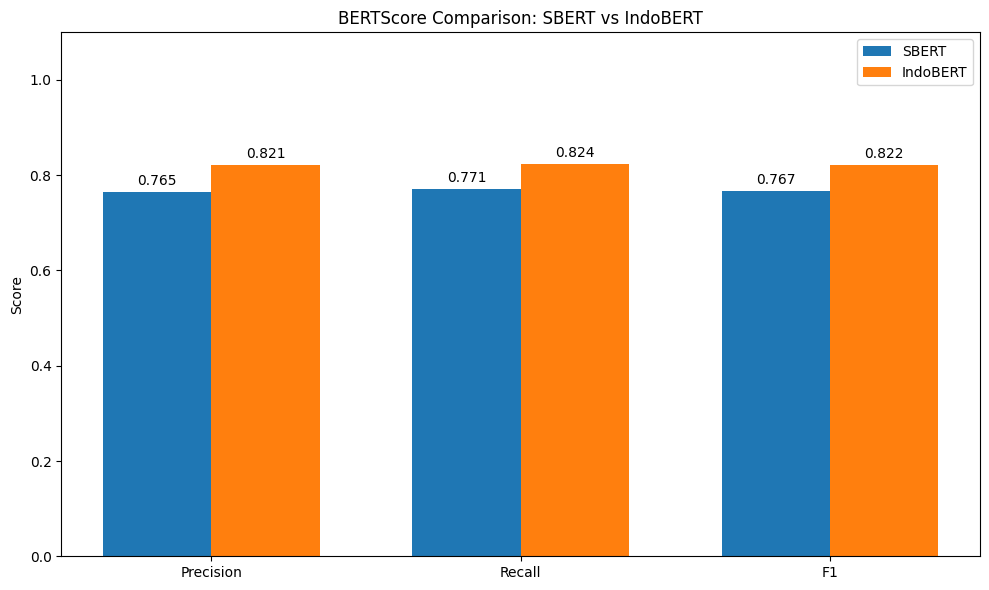

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# BERTScore results for SBERT (from cell EG-ploYNYKSW)
sbert_precision = 0.7651200890541077
sbert_recall = 0.7706587910652161
sbert_f1 = 0.7674663662910461

# BERTScore results for IndoBERT (from cell xF14IQ6-CUrk)
indobert_precision = 0.8209665417671204
indobert_recall = 0.824022650718689
indobert_f1 = 0.8220878839492798

metrics = ['Precision', 'Recall', 'F1']
sbert_scores = [sbert_precision, sbert_recall, sbert_f1]
indobert_scores = [indobert_precision, indobert_recall, indobert_f1]

x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, sbert_scores, width, label='SBERT')
rects2 = ax.bar(x + width/2, indobert_scores, width, label='IndoBERT')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('BERTScore Comparison: SBERT vs IndoBERT')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1) # Set y-axis limit to clearly show scores

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()